In [4]:
from datasets import load_dataset
import pandas as pd
import numpy as np

print("Loading dataset from Hugging Face...")

# Use a different dataset that works with current Hugging Face
dataset = load_dataset("zefang-liu/phishing-email-dataset")

# Convert to pandas dataframes
df_train = pd.DataFrame(dataset['train'])

# Split manually into train and test (80/20)
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df_train, test_size=0.2, random_state=42)
df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

# Check column names and rename if needed
print(f"Columns: {list(df_train.columns)}")

# Standardise column names to 'text' and 'label'
if 'Email Text' in df_train.columns:
    df_train = df_train.rename(columns={'Email Text': 'text', 'Email Type': 'label'})
    df_test  = df_test.rename(columns={'Email Text': 'text', 'Email Type': 'label'})

# Convert label to 0/1 if it is text
if df_train['label'].dtype == object:
    df_train['label'] = (df_train['label'] == 'Phishing Email').astype(int)
    df_test['label']  = (df_test['label']  == 'Phishing Email').astype(int)

print(f"\n✅ Dataset loaded successfully")
print(f"   Training samples : {len(df_train):,}")
print(f"   Test samples     : {len(df_test):,}")
print(f"\nLabel distribution (train):")
print(df_train['label'].value_counts().rename({0: 'Legitimate', 1: 'Phishing'}))

Loading dataset from Hugging Face...


README.md:   0%|          | 0.00/616 [00:00<?, ?B/s]

Phishing_Email.csv:   0%|          | 0.00/52.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/18650 [00:00<?, ? examples/s]

Columns: ['Unnamed: 0', 'Email Text', 'Email Type']

✅ Dataset loaded successfully
   Training samples : 14,920
   Test samples     : 3,730

Label distribution (train):
label
Legitimate    9049
Phishing      5871
Name: count, dtype: int64


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import time

# ── Clean data first ──────────────────────────────────────
# Remove any rows where email text is empty or None
df_train = df_train.dropna(subset=['text']).reset_index(drop=True)
df_test  = df_test.dropna(subset=['text']).reset_index(drop=True)

# Convert everything to string just to be safe
df_train['text'] = df_train['text'].astype(str)
df_test['text']  = df_test['text'].astype(str)

print(f"Clean training samples : {len(df_train):,}")
print(f"Clean test samples     : {len(df_test):,}")

# ── Build the ML pipeline ─────────────────────────────────
model = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=15000,
        ngram_range=(1, 2),
        stop_words='english',
        sublinear_tf=True
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        C=1.0,
        solver='lbfgs',
        n_jobs=-1
    ))
])

# ── Train ─────────────────────────────────────────────────
print("\nTraining model...")
start   = time.time()
model.fit(df_train['text'], df_train['label'])
elapsed = time.time() - start

print(f"✅ Model trained in {elapsed:.1f} seconds")
print(f"   Vocabulary size: {len(model.named_steps['tfidf'].vocabulary_):,} features")

Clean training samples : 14,906
Clean test samples     : 3,728

Training model...
✅ Model trained in 21.3 seconds
   Vocabulary size: 15,000 features


              precision    recall  f1-score   support

  Legitimate       0.98      0.97      0.98      2273
    Phishing       0.96      0.98      0.97      1455

    accuracy                           0.97      3728
   macro avg       0.97      0.97      0.97      3728
weighted avg       0.97      0.97      0.97      3728



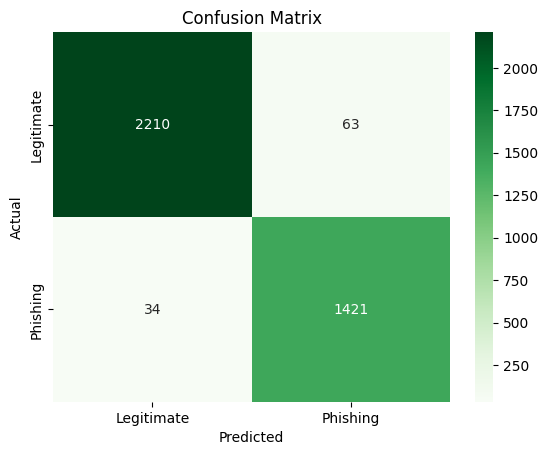

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on test set
y_pred = model.predict(df_test['text'])
y_true = df_test['label']

# Print precision, recall, F1
print(classification_report(y_true, y_pred,
      target_names=['Legitimate', 'Phishing']))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Legitimate','Phishing'],
            yticklabels=['Legitimate','Phishing'],
            cmap='Greens')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [10]:
def hybrid_phishing_score(email_text, ml_model):
    # Get ML probability (0 to 1)
    ml_prob = ml_model.predict_proba([email_text])[0][1]
    ml_score = ml_prob * 60  # ML contributes up to 60 points

    # Rule-based scoring layer
    rule_score = 0
    text_lower = email_text.lower()

    rules = {
        'urgent action required': 10,
        'verify your account': 10,
        'click here': 8,
        'password': 7,
        'bank account': 8,
        'limited time': 6,
        'congratulations you won': 10,
        'suspend': 7,
        'unusual activity': 8,
    }

    for phrase, score in rules.items():
        if phrase in text_lower:
            rule_score += score

    rule_score = min(rule_score, 40)  # Rule layer caps at 40 points

    total_score = ml_score + rule_score

    # Final verdict
    if total_score >= 60:
        verdict = "PHISHING"
    elif total_score >= 35:
        verdict = "SUSPICIOUS"
    else:
        verdict = "LEGITIMATE"

    return {
        'ml_probability': round(ml_prob, 3),
        'ml_score': round(ml_score, 1),
        'rule_score': round(rule_score, 1),
        'total_score': round(total_score, 1),
        'verdict': verdict
    }

# Test it on a sample email
test_email = """
Dear customer, your account has been suspended due to unusual activity.
Please click here to verify your password immediately or your account
will be permanently closed within 24 hours.
"""

result = hybrid_phishing_score(test_email, model)
print(result)


{'ml_probability': np.float64(0.903), 'ml_score': np.float64(54.2), 'rule_score': 30, 'total_score': np.float64(84.2), 'verdict': 'PHISHING'}


In [11]:
print(result)

{'ml_probability': np.float64(0.903), 'ml_score': np.float64(54.2), 'rule_score': 30, 'total_score': np.float64(84.2), 'verdict': 'PHISHING'}


In [13]:
def hybrid_phishing_score(email_text, ml_model):
    ml_prob = float(ml_model.predict_proba([email_text])[0][1])  # convert
    ml_score = float(ml_prob * 60)                               # convert
    ...
    total_score = float(ml_score + rule_score)                   # convert
    ...
    return {
        'ml_probability': round(ml_prob, 3),
        'ml_score': round(ml_score, 1),
        'rule_score': round(rule_score, 1),
        'total_score': round(total_score, 1),
        'verdict': verdict
    }

In [14]:
print(result)


{'ml_probability': np.float64(0.903), 'ml_score': np.float64(54.2), 'rule_score': 30, 'total_score': np.float64(84.2), 'verdict': 'PHISHING'}


In [15]:
legit_email = """
Hi team, reminder our meeting is at 3pm tomorrow.
Please review the agenda and share feedback. Thanks.
"""
print(hybrid_phishing_score(legit_email, model))

NameError: name 'rule_score' is not defined

In [16]:
import re

def hybrid_phishing_score(email_text, ml_model):
    # ML probability
    ml_prob = float(ml_model.predict_proba([email_text])[0][1])
    ml_score = ml_prob * 60

    # Rule-based scoring
    rule_score = 0
    text_lower = email_text.lower()

    rules = {
        'urgent action required': 10,
        'verify your account': 10,
        'click here': 8,
        'password': 7,
        'bank account': 8,
        'limited time': 6,
        'congratulations you won': 10,
        'suspend': 7,
        'unusual activity': 8,
    }

    for phrase, score in rules.items():
        if phrase in text_lower:
            rule_score += score

    # URL detection bonus
    if re.search(r'http[s]?://', text_lower):
        rule_score += 10

    rule_score = min(rule_score, 40)

    total_score = ml_score + rule_score

    # Final verdict
    if total_score >= 60:
        verdict = "PHISHING"
    elif total_score >= 35:
        verdict = "SUSPICIOUS"
    else:
        verdict = "LEGITIMATE"

    return {
        'ml_probability': round(ml_prob, 3),
        'ml_score': round(ml_score, 1),
        'rule_score': round(rule_score, 1),
        'total_score': round(total_score, 1),
        'verdict': verdict
    }

In [17]:
print(hybrid_phishing_score(legit_email, model))

{'ml_probability': 0.081, 'ml_score': 4.9, 'rule_score': 0, 'total_score': 4.9, 'verdict': 'LEGITIMATE'}


In [18]:
tests = [
    ("LEGIT", "Hi team, reminder our meeting is at 3pm tomorrow. Please review the agenda. Thanks."),
    ("LEGIT", "Can you send me the updated report by Friday? Appreciate it."),
    ("PHISH", "Urgent action required: verify your account now. Click here to reset password."),
    ("PHISH", "Your bank account has unusual activity. Please click here to confirm your password."),
    ("PHISH", "Congratulations you won! Limited time offer, claim now: http://bit.ly/xxxx")
]

for label, text in tests:
    out = hybrid_phishing_score(text, model)
    print(label, "=>", out)
    print("-"*70)

LEGIT => {'ml_probability': 0.062, 'ml_score': 3.7, 'rule_score': 0, 'total_score': 3.7, 'verdict': 'LEGITIMATE'}
----------------------------------------------------------------------
LEGIT => {'ml_probability': 0.202, 'ml_score': 12.1, 'rule_score': 0, 'total_score': 12.1, 'verdict': 'LEGITIMATE'}
----------------------------------------------------------------------
PHISH => {'ml_probability': 0.916, 'ml_score': 54.9, 'rule_score': 35, 'total_score': 89.9, 'verdict': 'PHISHING'}
----------------------------------------------------------------------
PHISH => {'ml_probability': 0.871, 'ml_score': 52.3, 'rule_score': 31, 'total_score': 83.3, 'verdict': 'PHISHING'}
----------------------------------------------------------------------
PHISH => {'ml_probability': 0.8, 'ml_score': 48.0, 'rule_score': 26, 'total_score': 74.0, 'verdict': 'PHISHING'}
----------------------------------------------------------------------


              precision    recall  f1-score   support

  Legitimate       0.95      0.99      0.97      2273
    Phishing       0.98      0.92      0.95      1455

    accuracy                           0.96      3728
   macro avg       0.96      0.95      0.96      3728
weighted avg       0.96      0.96      0.96      3728



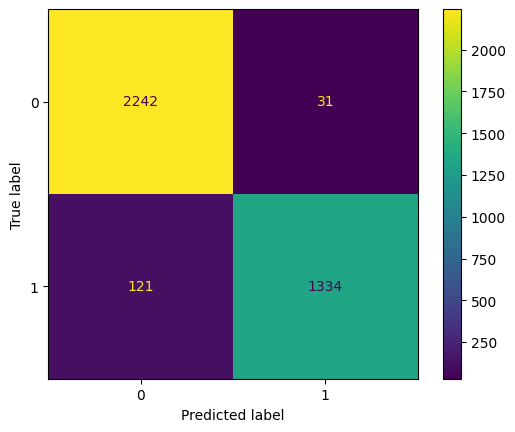

In [19]:
import numpy as np

def hybrid_predict_label(text):
    v = hybrid_phishing_score(text, model)['verdict']
    # convert verdict to label: treat SUSPICIOUS as PHISHING (safer)
    return 1 if v in ["PHISHING", "SUSPICIOUS"] else 0

y_true = df_test['label'].values
y_hybrid = np.array([hybrid_predict_label(t) for t in df_test['text'].astype(str)])

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(y_true, y_hybrid, target_names=['Legitimate','Phishing']))

cm = confusion_matrix(y_true, y_hybrid)
ConfusionMatrixDisplay(cm).plot()
plt.show()

In [20]:
print(df_train.shape)
print(df_train.columns)


(14906, 3)
Index(['Unnamed: 0', 'text', 'label'], dtype='object')


In [22]:
df_train.sample(5)

,Unnamed: 0,text,label
3461,14815,free 1 week dvd downloads we are happy to offe...,1
10520,5991,\nThe following advertisement is being sponsor...,1
2561,14185,URL: http://diveintomark.org/archives/2002/10/...,0
490,3099,when was the last time you spoilt yourself ? h...,1
1793,2004,<!--\n body { BACKGROUND-IMAGE: url(http:...,0


In [21]:
df_train.head()

,Unnamed: 0,text,label
0,2562,Matthew French's [mfrench42@yahoo.co.uk] 65 li...,0
1,398,\nBTW: I remember messing about with such thi...,0
2,17754,ngi ' s transwestern article article in today ...,0
3,16239,Sorry about that :) Didn't think before sendin...,0
4,1805,"re : wednesday lunch - credit group hi , every...",0
